In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Cargar datos
df = pd.read_csv('../data/empleados_ibm.csv')

# 2. Selección de variables críticas 
# Vamos a usar: Edad, Sueldo, Horas Extra y Años en la empresa
df['OverTime_Num'] = df['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Attrition_Num'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Elegimos nuestras "Features" (X) y nuestro "Target" (y)
X = df[['Age', 'MonthlyIncome', 'OverTime_Num', 'TotalWorkingYears']]
y = df['Attrition_Num']

# 3. Dividir los datos: 80% para entrenar y 20% para "examen" final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} empleados")
print(f"Datos de prueba: {X_test.shape[0]} empleados")

Datos de entrenamiento: 1176 empleados
Datos de prueba: 294 empleados


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Crear el modelo (El "Cerebro" vacío)
modelo = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenar (El modelo estudia el 80% de los datos)
modelo.fit(X_train, y_train)

# 3. Predecir (Le hacemos el examen con el 20% que no conoce)
predicciones = modelo.predict(X_test)

# 4. Ver los resultados
print(f"Precisión del modelo: {accuracy_score(y_test, predicciones):.2f}")
print("\nReporte Detallado:")
print(classification_report(y_test, predicciones))

Precisión del modelo: 0.81

Reporte Detallado:
              precision    recall  f1-score   support

           0       0.87      0.92      0.90       255
           1       0.17      0.10      0.13        39

    accuracy                           0.81       294
   macro avg       0.52      0.51      0.51       294
weighted avg       0.78      0.81      0.79       294



C:\Users\pardo\AppData\Local\Temp\ipykernel_12952\4126595609.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancia, x='Importancia', y='Variable', palette='magma')


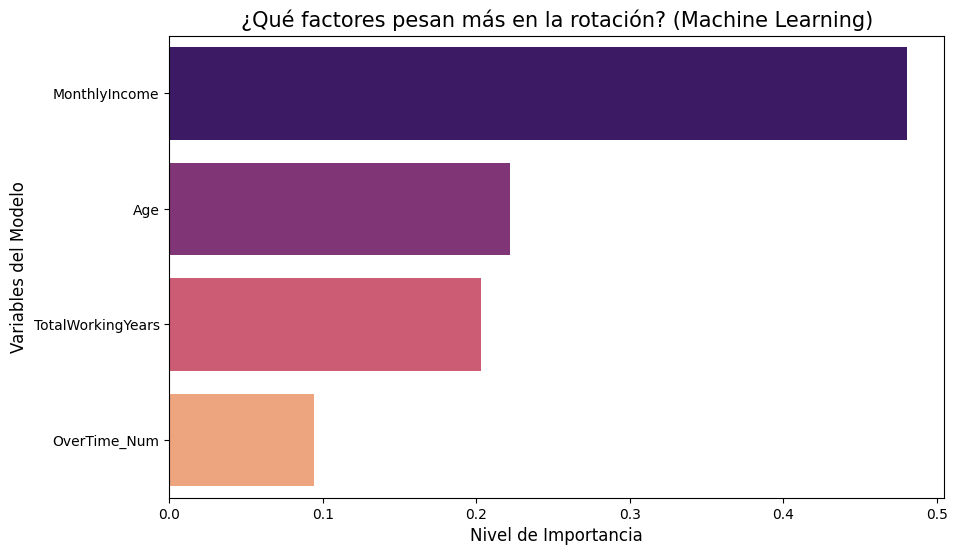

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraer las importancias del modelo
importancias = modelo.feature_importances_
nombres_variables = X.columns

# 2. Crear un DataFrame para facilitar la graficación
df_importancia = pd.DataFrame({'Variable': nombres_variables, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# 3. Graficar
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia, x='Importancia', y='Variable', palette='magma')

plt.title('¿Qué factores pesan más en la rotación? (Machine Learning)', fontsize=15)
plt.xlabel('Nivel de Importancia', fontsize=12)
plt.ylabel('Variables del Modelo', fontsize=12)

# Guardar la gráfica
plt.savefig('../reports/importancia_variables_ml.png')
plt.show()